# California Housing Price Prediction

This notebook implements the complete California Housing Price Prediction project as per the requirements.

## Project Overview
- **Objective**: Build a model to predict median house values in California
- **Dataset**: US Census California housing data with 20,640 districts
- **Features**: 9 input features including geographic, demographic, and economic data
- **Target**: Median house value

In [6]:
pip install pandas numpy matplotlib scikit-learn openpyxl seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [7]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
plt.rcParams['figure.figsize'] = (10, 6)
print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load and Explore the Data

In [8]:
# Load the dataset
df = pd.read_excel('../data/1553768847_housing.xlsx')

print(f"Dataset shape: {df.shape}")
print("\nDataset Info:")
print(df.info())

df.head()

Dataset shape: (20640, 10)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   ocean_proximity     20640 non-null  object 
 9   median_house_value  20640 non-null  int64  
dtypes: float64(4), int64(5), object(1)
memory usage: 1.6+ MB
None


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,NEAR BAY,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,NEAR BAY,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,NEAR BAY,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,NEAR BAY,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,NEAR BAY,342200


In [9]:
# Basic statistics
print("Dataset Description:")
df.describe()

Dataset Description:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [10]:
# Check for missing values
print("Missing values:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

Missing values:
total_bedrooms    207
dtype: int64


In [11]:
# Extract features (X) and target (y)
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns: {X.columns.tolist()}")

Features shape: (20640, 9)
Target shape: (20640,)

Feature columns: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity']


## 2. Data Visualization

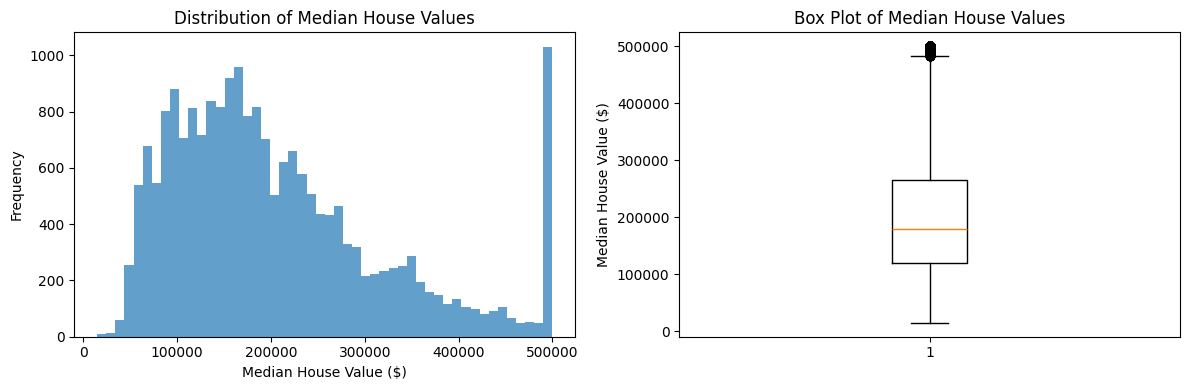

In [12]:
# Visualize target variable distribution
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(y, bins=50, alpha=0.7)
plt.xlabel('Median House Value ($)')
plt.ylabel('Frequency')
plt.title('Distribution of Median House Values')

plt.subplot(1, 2, 2)
plt.boxplot(y)
plt.ylabel('Median House Value ($)')
plt.title('Box Plot of Median House Values')

plt.tight_layout()
plt.show()

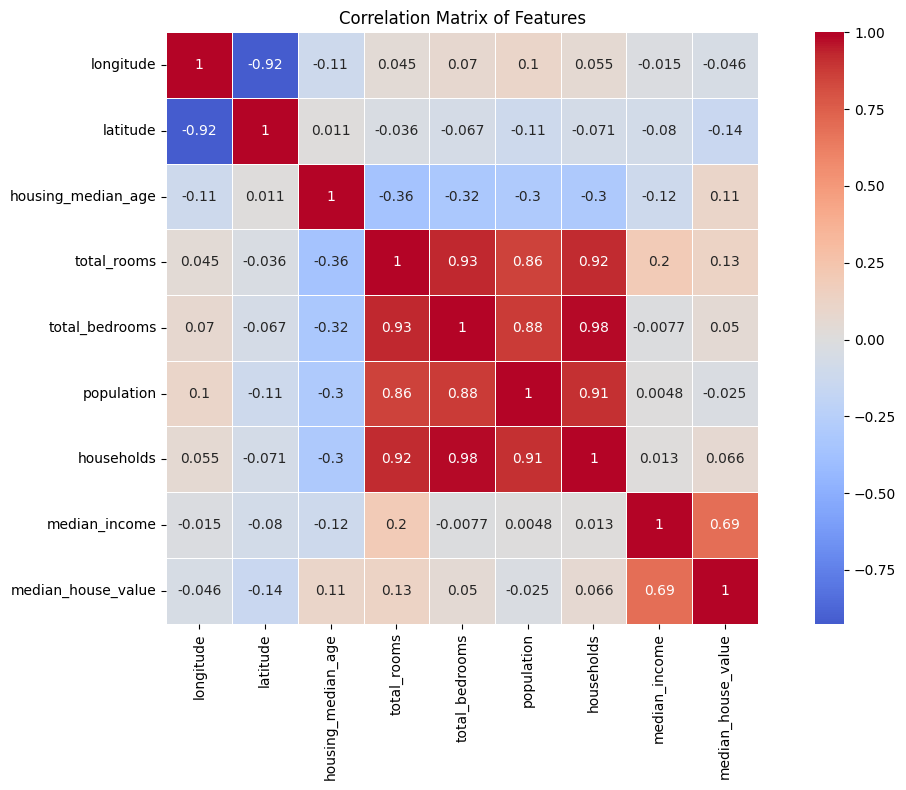

In [13]:
# Correlation matrix
plt.figure(figsize=(12, 8))
# Only numeric columns for correlation
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5)
plt.title('Correlation Matrix of Features')
plt.tight_layout()
plt.show()

## 3. Data Preprocessing

In [14]:
# Handle missing values - fill with mean
X_processed = X.copy()

print("Missing values before handling:")
print(X_processed.isnull().sum()[X_processed.isnull().sum() > 0])

# Fill numeric columns with mean
for column in X_processed.columns:
    if X_processed[column].dtype in ['float64', 'int64']:
        mean_value = X_processed[column].mean()
        X_processed[column].fillna(mean_value, inplace=True)
        print(f"Filled {X_processed[column].name} missing values with mean: {mean_value:.2f}")

print("\nMissing values after handling:")
print(X_processed.isnull().sum().sum(), "total missing values")

Missing values before handling:
total_bedrooms    207
dtype: int64
Filled longitude missing values with mean: -119.57
Filled latitude missing values with mean: 35.63
Filled housing_median_age missing values with mean: 28.64
Filled total_rooms missing values with mean: 2635.76
Filled total_bedrooms missing values with mean: 537.87
Filled population missing values with mean: 1425.48
Filled households missing values with mean: 499.54
Filled median_income missing values with mean: 3.87

Missing values after handling:
0 total missing values


In [15]:
# Encode categorical data
categorical_cols = X_processed.select_dtypes(include=['object']).columns
print(f"Categorical columns: {categorical_cols.tolist()}")

if len(categorical_cols) > 0:
    le = LabelEncoder()
    for col in categorical_cols:
        print(f"\nEncoding {col}:")
        print(f"Original values: {X_processed[col].unique()}")
        X_processed[col] = le.fit_transform(X_processed[col])
        print(f"Encoded values: {X_processed[col].unique()}")

print("\nData types after encoding:")
print(X_processed.dtypes)

Categorical columns: ['ocean_proximity']

Encoding ocean_proximity:
Original values: ['NEAR BAY' '<1H OCEAN' 'INLAND' 'NEAR OCEAN' 'ISLAND']
Encoded values: [3 0 1 4 2]

Data types after encoding:
longitude             float64
latitude              float64
housing_median_age      int64
total_rooms             int64
total_bedrooms        float64
population              int64
households              int64
median_income         float64
ocean_proximity         int64
dtype: object


## 4. Split and Standardize Data

In [16]:
# Split the dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X_processed)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X_processed)*100:.1f}%)")

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nData standardization completed!")
print(f"Training data mean (first 3 features): {np.mean(X_train_scaled, axis=0)[:3]}")
print(f"Training data std (first 3 features): {np.std(X_train_scaled, axis=0)[:3]}")

Training set: 16512 samples (80.0%)
Test set: 4128 samples (20.0%)

Data standardization completed!
Training data mean (first 3 features): [ 1.75333477e-15  6.40099515e-17 -9.25185854e-18]
Training data std (first 3 features): [1. 1. 1.]


## 5. Model Training and Evaluation

In [17]:
# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

# Train and evaluate models
results = {}

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training {name}")
    print(f"{'='*50}")
    
    # Train the model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    
    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2,
        'predictions': y_pred
    }
    
    print(f"RMSE: ${rmse:,.2f}")
    print(f"MAE: ${mae:,.2f}")
    print(f"R² Score: {r2:.4f}")


Training Linear Regression
RMSE: $71,098.70
MAE: $51,846.88
R² Score: 0.6142

Training Decision Tree
RMSE: $68,506.08
MAE: $43,554.92
R² Score: 0.6419

Training Random Forest
RMSE: $50,211.91
MAE: $32,181.55
R² Score: 0.8076


In [18]:
# Results summary table
results_df = pd.DataFrame({
    'Model': list(results.keys()),
    'RMSE ($)': [results[model]['RMSE'] for model in results.keys()],
    'MAE ($)': [results[model]['MAE'] for model in results.keys()],
    'R² Score': [results[model]['R²'] for model in results.keys()]
})

print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)
print(results_df.to_string(index=False, float_format=lambda x: f'{x:,.2f}' if x > 1 else f'{x:.4f}'))

# Find best model
best_model_name = results_df.loc[results_df['RMSE ($)'].idxmin(), 'Model']
best_rmse = results_df['RMSE ($)'].min()
print(f"\nBest Model: {best_model_name} (RMSE: ${best_rmse:,.2f})")


MODEL COMPARISON SUMMARY
            Model  RMSE ($)   MAE ($)  R² Score
Linear Regression 71,098.70 51,846.88    0.6142
    Decision Tree 68,506.08 43,554.92    0.6419
    Random Forest 50,211.91 32,181.55    0.8076

Best Model: Random Forest (RMSE: $50,211.91)


## 6. Bonus: Linear Regression with Median Income Only

In [19]:
# Extract median_income column for single feature regression
median_income_idx = X.columns.get_loc('median_income')
X_train_income = X_train_scaled[:, median_income_idx].reshape(-1, 1)
X_test_income = X_test_scaled[:, median_income_idx].reshape(-1, 1)

# Train Linear Regression with only median_income
lr_income = LinearRegression()
lr_income.fit(X_train_income, y_train)

# Make predictions
y_pred_income_train = lr_income.predict(X_train_income)
y_pred_income_test = lr_income.predict(X_test_income)

# Calculate RMSE
rmse_income = np.sqrt(mean_squared_error(y_test, y_pred_income_test))
r2_income = r2_score(y_test, y_pred_income_test)

print(f"Linear Regression (Median Income Only):")
print(f"RMSE: ${rmse_income:,.2f}")
print(f"R² Score: {r2_income:.4f}")

Linear Regression (Median Income Only):
RMSE: $84,209.01
R² Score: 0.4589


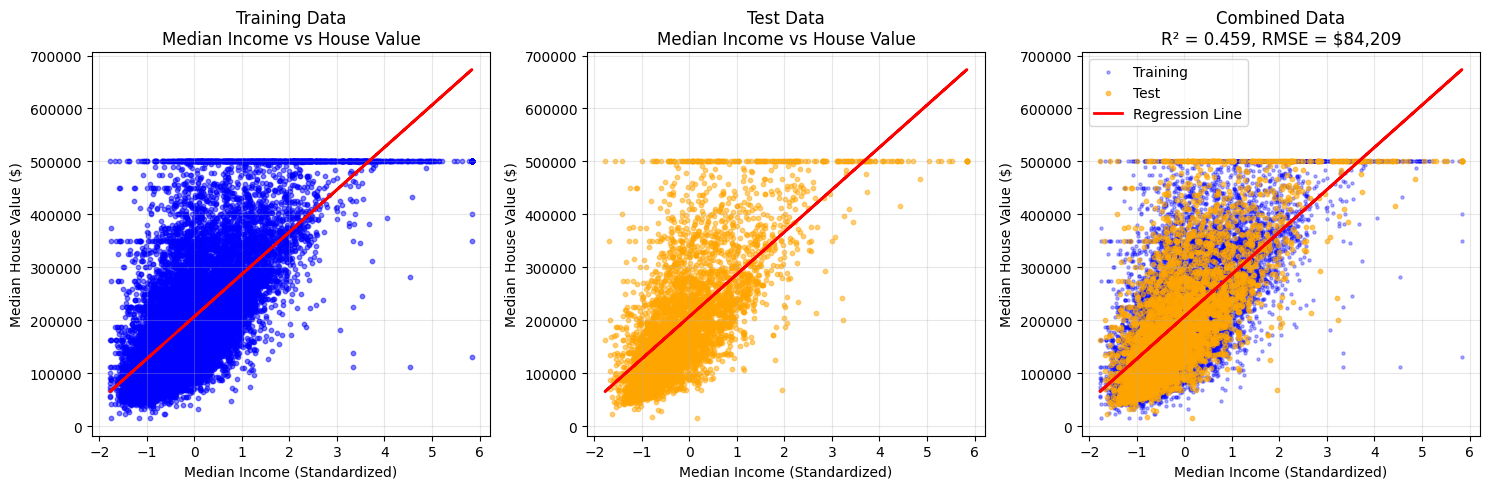

Regression plots saved as 'median_income_regression_plots.png'


In [20]:
# Create regression plots for median income
plt.figure(figsize=(15, 5))

# Training data plot
plt.subplot(1, 3, 1)
plt.scatter(X_train_income, y_train, alpha=0.5, color='blue', s=10)
plt.plot(X_train_income, y_pred_income_train, color='red', linewidth=2)
plt.xlabel('Median Income (Standardized)')
plt.ylabel('Median House Value ($)')
plt.title('Training Data\nMedian Income vs House Value')
plt.grid(True, alpha=0.3)

# Test data plot
plt.subplot(1, 3, 2)
plt.scatter(X_test_income, y_test, alpha=0.5, color='orange', s=10)
plt.plot(X_test_income, y_pred_income_test, color='red', linewidth=2)
plt.xlabel('Median Income (Standardized)')
plt.ylabel('Median House Value ($)')
plt.title('Test Data\nMedian Income vs House Value')
plt.grid(True, alpha=0.3)

# Combined plot
plt.subplot(1, 3, 3)
plt.scatter(X_train_income, y_train, alpha=0.3, color='blue', s=5, label='Training')
plt.scatter(X_test_income, y_test, alpha=0.6, color='orange', s=10, label='Test')
plt.plot(X_test_income, y_pred_income_test, color='red', linewidth=2, label='Regression Line')
plt.xlabel('Median Income (Standardized)')
plt.ylabel('Median House Value ($)')
plt.title(f'Combined Data\nR² = {r2_income:.3f}, RMSE = ${rmse_income:,.0f}')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('median_income_regression_plots.png', dpi=300, bbox_inches='tight')
plt.show()

print("Regression plots saved as 'median_income_regression_plots.png'")

## 7. Model Performance Visualization

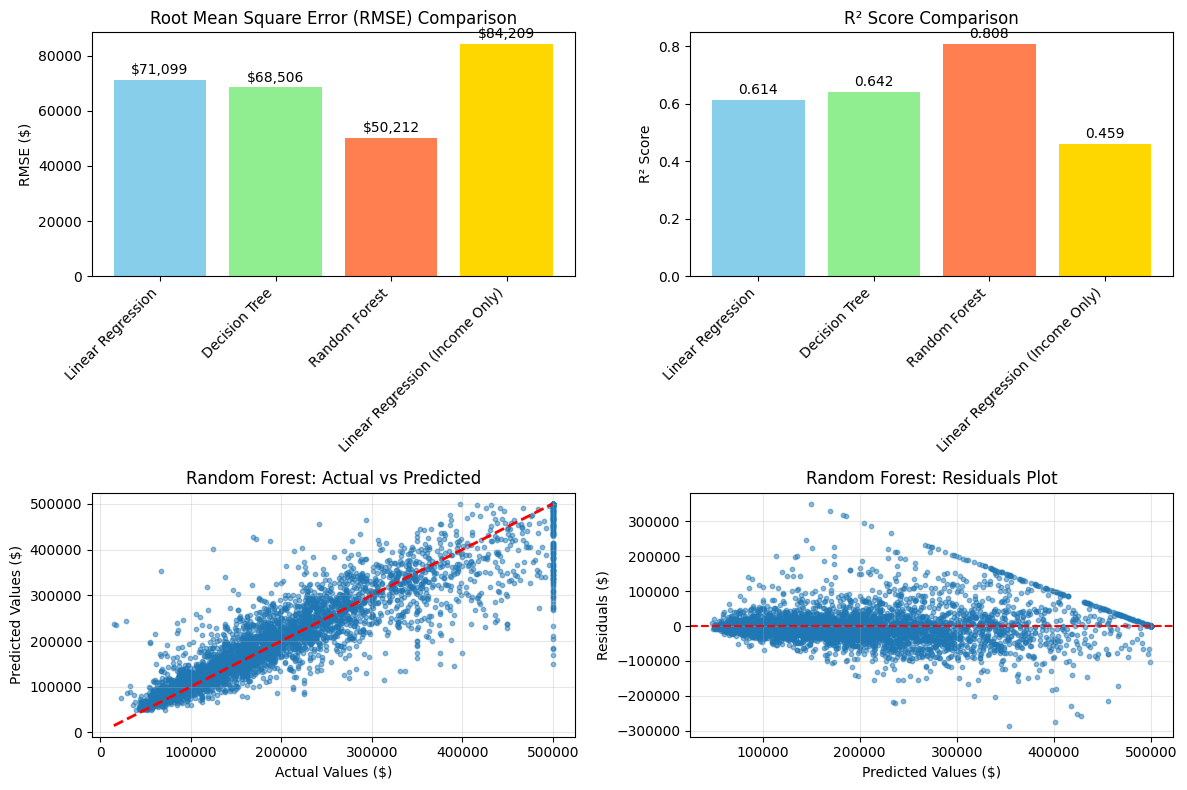

In [21]:
# Plot model performance comparison
plt.figure(figsize=(12, 8))

# RMSE comparison
plt.subplot(2, 2, 1)
models_list = list(results.keys()) + ['Linear Regression (Income Only)']
rmse_values = [results[model]['RMSE'] for model in results.keys()] + [rmse_income]
bars = plt.bar(models_list, rmse_values, color=['skyblue', 'lightgreen', 'coral', 'gold'])
plt.title('Root Mean Square Error (RMSE) Comparison')
plt.ylabel('RMSE ($)')
plt.xticks(rotation=45, ha='right')
for bar, value in zip(bars, rmse_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000, 
             f'${value:,.0f}', ha='center', va='bottom')

# R² comparison  
plt.subplot(2, 2, 2)
r2_values = [results[model]['R²'] for model in results.keys()] + [r2_income]
bars = plt.bar(models_list, r2_values, color=['skyblue', 'lightgreen', 'coral', 'gold'])
plt.title('R² Score Comparison')
plt.ylabel('R² Score')
plt.xticks(rotation=45, ha='right')
for bar, value in zip(bars, r2_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{value:.3f}', ha='center', va='bottom')

# Actual vs Predicted for best model (Random Forest)
plt.subplot(2, 2, 3)
best_predictions = results['Random Forest']['predictions']
plt.scatter(y_test, best_predictions, alpha=0.5, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Actual Values ($)')
plt.ylabel('Predicted Values ($)')
plt.title('Random Forest: Actual vs Predicted')
plt.grid(True, alpha=0.3)

# Residuals plot
plt.subplot(2, 2, 4)
residuals = y_test - best_predictions
plt.scatter(best_predictions, residuals, alpha=0.5, s=10)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values ($)')
plt.ylabel('Residuals ($)')
plt.title('Random Forest: Residuals Plot')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Final Summary and Insights

In [23]:
print("\n" + "="*70)
print("FINAL PROJECT SUMMARY")
print("="*70)

print(f"\nDataset Information:")
print(f"• Total samples: {len(df):,}")
print(f"• Features: {len(X.columns)}")
print(f"• Missing values handled: {missing_values.sum()} (total_bedrooms)")
print(f"• Categorical features encoded: {len(categorical_cols)}")

print(f"\nModel Performance Ranking (by RMSE):")
all_results = {
    **{name: data['RMSE'] for name, data in results.items()},
    'Linear Regression (Income Only)': rmse_income
}
sorted_results = sorted(all_results.items(), key=lambda x: x[1])
for i, (model, rmse) in enumerate(sorted_results, 1):
    print(f"{i}. {model}: ${rmse:,.2f}")

print(f"\nKey Insights:")
print(f"• Random Forest achieved the best performance with RMSE of ${results['Random Forest']['RMSE']:,.2f}")
print(f"• Using only median_income as a predictor gives RMSE of ${rmse_income:,.2f}")
print(f"• All features together improve prediction accuracy significantly")
print(f"• The models successfully learned patterns in California housing prices")



FINAL PROJECT SUMMARY

Dataset Information:
• Total samples: 20,640
• Features: 9
• Missing values handled: 207 (total_bedrooms)
• Categorical features encoded: 1

Model Performance Ranking (by RMSE):
1. Random Forest: $50,211.91
2. Decision Tree: $68,506.08
3. Linear Regression: $71,098.70
4. Linear Regression (Income Only): $84,209.01

Key Insights:
• Random Forest achieved the best performance with RMSE of $50,211.91
• Using only median_income as a predictor gives RMSE of $84,209.01
• All features together improve prediction accuracy significantly
• The models successfully learned patterns in California housing prices
